# ROGII Wellbore Geology - Dense (MLP) Hyperparameter Optimization

Find the optimal Dense (MLP) network configuration using **Keras Tuner Hyperband**.

**Features (6):** `MD, X, Y, Z, GR, TVT_input`  
**Label:** `TVT`  
**Backend**: Keras 3 + JAX backend

**Author**: Samir Attrah

In [1]:
"""Environment setup and library imports for hyperparameter optimization of a Dense (MLP) model.

Sets Keras JAX backend and configures JAX precision and allocation behavior.
"""

import os

os.environ["KERAS_BACKEND"] = "jax"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"

import jax

# Enable JAX float64 precision natively
jax.config.update("jax_enable_x64", True)

import keras
from keras import callbacks, layers, regularizers
import keras_tuner as kt
import jax.numpy as jnp
import numpy as np
import polars as pl
import glob
import pickle
import random
import warnings

warnings.filterwarnings("ignore")

# Show enough digits to round-trip float64 diagnostics
np.set_printoptions(precision=17, floatmode="unique")

# Set seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

print(f"Keras version : {keras.__version__}")
print(f"Keras backend : {keras.backend.backend()}")
print(f"Working dir   : {os.getcwd()}")


2026-07-17 12:15:49.744347: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1784279749.791143  224262 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1784279749.805026  224262 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Keras version : 3.12.0
Keras backend : jax
Working dir   : /home/samer/Documents/competitions/ROGII/notebooks


### 2. Auto-detect Dataset Path
Locate the competition dataset in local or Kaggle environments.

In [2]:
def find_data_dir():
    """Searches common Kaggle mount points for the ROGII dataset.

    Returns:
        str: Path to the dataset directory containing 'train' subdirectory.

    Raises:
        FileNotFoundError: If the dataset cannot be found in any candidate path.
    """
    candidates = [
        "/kaggle/input/competitions/rogii-wellbore-geology-prediction",
        "/kaggle/input/rogii-wellbore-geology-prediction",
        "/home/samer/Documents/competitions/ROGII/dataset",
    ]

    for scan_root in ["/kaggle/input", "/kaggle/input/competitions"]:
        if os.path.isdir(scan_root):
            for entry in os.listdir(scan_root):
                full = os.path.join(scan_root, entry)
                if os.path.isdir(full) and full not in candidates:
                    candidates.append(full)

    print("Searching for ROGII dataset...")
    for path in candidates:
        if not os.path.isdir(path):
            continue

        contents = os.listdir(path)
        has_train = "train" in contents and os.path.isdir(os.path.join(path, "train"))
        n_train = 0
        if has_train:
            n_train = len(
                glob.glob(os.path.join(path, "train", "*__horizontal_well.csv"))
            )

        if n_train > 0:
            print(f"  V Using {path} (found {n_train} train wells)")
            return path

    raise FileNotFoundError("Could not find ROGII dataset.")


DATA_DIR = find_data_dir()


Searching for ROGII dataset...
  V Using /home/samer/Documents/competitions/ROGII/dataset (found 773 train wells)


### 3. Data helpers & Preparation
Functions for loading well logs, masking `TVT_input` like the test prediction interval, preprocessing with Polars, and standardizing with JAX in float64 precision.

In [3]:
"""Data loading, preprocessing and preparation functions using Polars and JAX.

The dense model is trained with a test-like TVT_input mask. In the competition test
wells, TVT_input is known before the submission interval and missing throughout the
interval that must be predicted. If validation keeps the true TVT_input, the model can
learn an identity shortcut and report unrealistically low validation RMSE.
"""

FEATURE_COLS = ["MD", "X", "Y", "Z", "GR", "TVT_input"]
TARGET = "TVT"
TVT_INPUT_COL = "TVT_input"
MASK_START_RATIO_RANGE = (0.20, 0.40)


def mask_tvt_input_for_prediction_zone(df, rng, ratio_range=MASK_START_RATIO_RANGE):
    """Masks a suffix of TVT_input to mimic the hidden test prediction interval.

    Args:
        df (pl.DataFrame): Input DataFrame.
        rng (numpy.random.Generator): Random number generator.
        ratio_range (tuple): Range of mask start ratio.

    Returns:
        tuple: (Masked DataFrame, mask_start index).
    """
    if TVT_INPUT_COL not in df.columns or len(df) < 2:
        return df, len(df)

    low, high = ratio_range
    mask_start = int(round(len(df) * rng.uniform(low, high)))
    mask_start = min(max(mask_start, 1), len(df) - 1)
    row_nr = pl.int_range(0, pl.len())
    df = df.with_columns(
        pl.when(row_nr >= mask_start)
        .then(None)
        .otherwise(pl.col(TVT_INPUT_COL))
        .alias(TVT_INPUT_COL)
    )
    return df, mask_start


def preprocess(df):
    """Interpolates and fills null values in the feature columns.

    Args:
        df (pl.DataFrame): Input DataFrame.

    Returns:
        pl.DataFrame: Preprocessed DataFrame.
    """
    for col in FEATURE_COLS:
        if col in df.columns:
            df = df.with_columns(
                pl.col(col)
                .interpolate()
                .fill_null(strategy="forward")
                .fill_null(strategy="backward")
                .fill_null(0.0)
            )
    return df


def prepare_data(data_dir, val_ratio=0.20, seed=42, max_wells=None):
    """Loads wells and builds train/validation arrays with test-like masking.

    Args:
        data_dir (str): Path to the training dataset.
        val_ratio (float): Fraction of wells to use for validation.
        seed (int): Random seed.
        max_wells (int): Maximum number of wells to load.

    Returns:
        tuple: (X_train, y_train, X_val, y_val, y_val_raw, scaler_params).
    """
    dataset_root = os.path.dirname(data_dir)

    # 1. Get original training IDs
    pattern_train = os.path.join(data_dir, "train", "*__horizontal_well.csv")
    files_train = sorted([os.path.basename(f) for f in glob.glob(pattern_train)])

    # 2. Get augmented training files
    pattern_aug = os.path.join(
        dataset_root, "dataset_augmented", "train", "*__horizontal_well_aug.csv"
    )
    files_aug = sorted([os.path.basename(f) for f in glob.glob(pattern_aug)])

    # Combined training file list
    files_train_all = files_train + files_aug

    if max_wells:
        files_train_all = files_train_all[:max_wells]

    rng = np.random.default_rng(seed)
    n_val = max(1, int(len(files_train_all) * val_ratio))
    val_set = set(rng.permutation(len(files_train_all))[:n_val])

    train_files = [fname for i, fname in enumerate(files_train_all) if i not in val_set]
    val_files = [fname for i, fname in enumerate(files_train_all) if i in val_set]

    print(
        f"Loading {len(files_train_all)} training wells total. "
        f"(Original: {len(files_train)}, Augmented: {len(files_aug)})."
    )

    def get_arrays(files, split_name):
        feats, tgts, mask_starts = [], [], []
        for filename in files:
            try:
                if filename in files_aug:
                    path = os.path.join(
                        dataset_root, "dataset_augmented", "train", filename
                    )
                else:
                    path = os.path.join(data_dir, "train", filename)

                df = pl.read_csv(path, infer_schema_length=10000)
                df = df.filter(pl.col(TARGET).is_not_null())
                if len(df) == 0:
                    continue

                df, mask_start = mask_tvt_input_for_prediction_zone(df, rng)
                df = preprocess(df)

                feats.append(df.select(FEATURE_COLS).to_numpy().astype(np.float64))
                tgts.append(df.select(TARGET).to_numpy().ravel().astype(np.float64))
                mask_starts.append(mask_start / len(df))
            except Exception as e:
                print(f"  Skip {filename}: {e}")

        if not feats:
            raise ValueError(f"No usable wells found for {split_name} split.")

        print(
            f"{split_name} TVT_input mask start ratio: "
            f"mean={np.mean(mask_starts):.3f}, "
            f"min={np.min(mask_starts):.3f}, max={np.max(mask_starts):.3f}"
        )
        return np.concatenate(feats), np.concatenate(tgts)

    X_train_raw, y_train_raw = get_arrays(train_files, "Train")
    X_val_raw, y_val_raw = get_arrays(val_files, "Val")

    feat_mean = jnp.mean(jnp.array(X_train_raw, dtype=jnp.float64), axis=0)
    feat_std = jnp.std(jnp.array(X_train_raw, dtype=jnp.float64), axis=0)
    feat_std = jnp.where(feat_std == 0, 1.0, feat_std)

    target_mean = jnp.mean(jnp.array(y_train_raw, dtype=jnp.float64))
    target_std = jnp.std(jnp.array(y_train_raw, dtype=jnp.float64))
    target_std = jnp.where(target_std == 0, 1.0, target_std)

    X_train_n = (jnp.array(X_train_raw, dtype=jnp.float64) - feat_mean) / feat_std
    y_train_n = (jnp.array(y_train_raw, dtype=jnp.float64) - target_mean) / target_std
    X_val_n = (jnp.array(X_val_raw, dtype=jnp.float64) - feat_mean) / feat_std
    y_val_n = (jnp.array(y_val_raw, dtype=jnp.float64) - target_mean) / target_std

    scaler = {
        "feature_cols": FEATURE_COLS,
        "feat_mean": np.array(feat_mean),
        "feat_std": np.array(feat_std),
        "target_mean": float(target_mean),
        "target_std": float(target_std),
        "normalized": True,
        "tvt_input_masked_for_training": True,
        "mask_start_ratio_range": MASK_START_RATIO_RANGE,
    }

    return (
        np.array(X_train_n, dtype=np.float32),
        np.array(y_train_n, dtype=np.float32),
        np.array(X_val_n, dtype=np.float32),
        np.array(y_val_n, dtype=np.float32),
        y_val_raw,
        scaler,
    )


print("Preparing dataset...")
X_train, y_train, X_val, y_val, y_val_raw, scaler = prepare_data(DATA_DIR)
print(f"Train size: {X_train.shape}, Val size: {X_val.shape}")

OUT_DIR = "../outputs"
os.makedirs(OUT_DIR, exist_ok=True)
scaler_path = os.path.join(OUT_DIR, "dense_opt_scaler_params.pkl")
with open(scaler_path, "wb") as f:
    pickle.dump(scaler, f)
print(f"Scaler parameters saved to {scaler_path}")

Preparing dataset...
Loading 1546 training wells total. (Original: 773, Augmented: 773).
Train TVT_input mask start ratio: mean=0.299, min=0.200, max=0.400
Val TVT_input mask start ratio: mean=0.303, min=0.201, max=0.400
Train size: (7920760, 6), Val size: (1994245, 6)
Scaler parameters saved to ../outputs/dense_opt_scaler_params.pkl


### 4. Define HyperModel & Tuner
Specify the search space for layers count, units, regularization rate, dropout rates, learning rate, and gradient clipping norm using Keras Tuner Hyperband.

In [ ]:
class DenseHyperModel(kt.HyperModel):
    """Hyperparameter search space for Multi-Layer Perceptron (MLP) model.

    Tunes depth, units per layer, activation function, kernel initializer,
    regularization, dropout, global gradient clipping, and Adam optimizer settings.
    """

    def __init__(self, input_dim):
        """Initializes the hypermodel.

        Args:
            input_dim (int): Dimensionality of the input features.
        """
        super().__init__()
        self.input_dim = input_dim

    def build(self, hp):
        """Builds a dense neural network (MLP) with tunable hyperparameters.

        Args:
            hp (kt.HyperParameters): Keras Tuner hyperparameter object.

        Returns:
            keras.Model: Compiled Keras model.
        """
        model = keras.Sequential()
        model.add(layers.Input(shape=(self.input_dim,)))

        # Tune the number of hidden layers
        num_layers = hp.Int("num_layers", 2, 12, default=4)

        # Tune activation and initializer globally for all hidden layers
        activation = hp.Choice(
            "activation", ["linear", "relu", "selu", "tanh", "sigmoid"], default="relu"
        )
        initializer = hp.Choice(
            "initializer",
            ["glorot_uniform", "he_normal", "lecun_normal", "orthogonal"],
            default="glorot_uniform",
        )

        for i in range(num_layers):
            units = hp.Int(f"units_{i}", 16, 512, step=32, default=128)
            model.add(
                layers.Dense(
                    units,
                    activation=activation,
                    kernel_initializer=initializer,
                    kernel_regularizer=regularizers.L2(
                        hp.Float("kr_rate", 1e-6, 1e-3, sampling="log", default=1e-5)
                    ),
                )
            )
            dropout_rate = hp.Float(f"dropout_{i}", 0.0, 0.5, step=0.1, default=0.2)
            if dropout_rate > 0.0:
                model.add(layers.Dropout(dropout_rate))

        model.add(layers.Dense(1, activation="linear"))

        # Optimizer tuning
        optimizer_name = hp.Choice(
            "optimizer", ["Adam", "AdamW", "RMSprop"], default="Adam"
        )
        lr = hp.Float("lr", 1e-5, 1e-2, sampling="log", default=1e-3)

        if optimizer_name == "Adam":
            optimizer = keras.optimizers.Adam(learning_rate=lr)
        elif optimizer_name == "AdamW":
            optimizer = keras.optimizers.AdamW(
                learning_rate=lr,
                weight_decay=hp.Float("weight_decay", 1e-8, 1e-2, sampling="log"),
            )
        else:
            optimizer = keras.optimizers.RMSprop(learning_rate=lr)

        gcn = hp.Float("gcn", 0.5, 2.0, step=0.5, default=1.0)

        model.compile(
            optimizer=optimizer,
            loss="mse",
            metrics=[keras.metrics.RootMeanSquaredError(name="rmse")],
        )
        return model


# Initialize the Hyperband tuner
tuner = kt.Hyperband(
    DenseHyperModel(input_dim=len(FEATURE_COLS)),
    objective=kt.Objective("val_rmse", direction="min"),
    max_epochs=30,
    factor=3,
    hyperband_iterations=2,
    directory="tuner_results",
    project_name="rogii_dense_opt_norm_augmented_v2",
    overwrite=False,
)

print("Tuner initialized.")
tuner.search_space_summary()

Reloading Tuner from tuner_results/rogii_dense_opt_norm_augmented_v2/tuner0.json
Tuner initialized.
Search space summary
Default search space size: 31
num_layers (Int)
{'default': 4, 'conditions': [], 'min_value': 2, 'max_value': 12, 'step': 1, 'sampling': 'linear'}
activation (Choice)
{'default': 'relu', 'conditions': [], 'values': ['linear', 'relu', 'selu', 'tanh', 'sigmoid'], 'ordered': False}
initializer (Choice)
{'default': 'glorot_uniform', 'conditions': [], 'values': ['glorot_uniform', 'he_normal', 'lecun_normal', 'orthogonal'], 'ordered': False}
units_0 (Int)
{'default': 128, 'conditions': [], 'min_value': 16, 'max_value': 512, 'step': 32, 'sampling': 'linear'}
kr_rate (Float)
{'default': 1e-05, 'conditions': [], 'min_value': 1e-06, 'max_value': 0.001, 'step': None, 'sampling': 'log'}
dropout_0 (Float)
{'default': 0.2, 'conditions': [], 'min_value': 0.0, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
units_1 (Int)
{'default': 128, 'conditions': [], 'min_value': 16, 'max_v

### 5. Run Optimization Search
Run Hyperband search with EarlyStopping callback on validation RMSE.

In [7]:
"""Run the hyperparameter tuning search using Hyperband."""

# Define Keras Tuner HyperParameters to support tuning batch_size in tuner.search
hp = kt.HyperParameters()

# Increased patience to 10 for more robust evaluation during search
stop_early = callbacks.EarlyStopping(monitor="val_rmse", patience=10)

print("Starting hyperparameter search...")
tuner.search(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    batch_size=hp.Int("batch_size", 32, 512, step=32, default=128),
    callbacks=[stop_early],
)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\nSearch complete.")


Starting hyperparameter search...

Search: Running Trial #19

Value             |Best Value So Far |Hyperparameter
7                 |2                 |num_layers
sigmoid           |selu              |activation
orthogonal        |lecun_normal      |initializer
208               |496               |units_0
7.5004e-06        |2.0109e-05        |kr_rate
0.4               |0                 |dropout_0
400               |336               |units_1
0.3               |0                 |dropout_1
272               |304               |units_2
0.2               |0.4               |dropout_2
400               |112               |units_3
0.3               |0.1               |dropout_3
AdamW             |RMSprop           |optimizer
7.0378e-05        |0.00019443        |lr
1.5               |0.5               |gcn
464               |272               |units_4
0.1               |0                 |dropout_4
176               |48                |units_5
0.1               |0.1               |dropou

Traceback (most recent call last):
  File "/home/samer/anaconda3/envs/tensorflow/lib/python3.12/site-packages/keras_tuner/src/engine/base_tuner.py", line 274, in _try_run_and_update_trial
    self._run_and_update_trial(trial, *fit_args, **fit_kwargs)
  File "/home/samer/anaconda3/envs/tensorflow/lib/python3.12/site-packages/keras_tuner/src/engine/base_tuner.py", line 239, in _run_and_update_trial
    results = self.run_trial(trial, *fit_args, **fit_kwargs)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/samer/anaconda3/envs/tensorflow/lib/python3.12/site-packages/keras_tuner/src/tuners/hyperband.py", line 427, in run_trial
    return super().run_trial(trial, *fit_args, **fit_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/samer/anaconda3/envs/tensorflow/lib/python3.12/site-packages/keras_tuner/src/engine/tuner.py", line 314, in run_trial
    obj_value = self._build_and_fit_model(trial, *args, **copied_kwargs)
               

RuntimeError: Number of consecutive failures exceeded the limit of 3.
Traceback (most recent call last):
  File "/home/samer/anaconda3/envs/tensorflow/lib/python3.12/site-packages/keras_tuner/src/engine/base_tuner.py", line 274, in _try_run_and_update_trial
    self._run_and_update_trial(trial, *fit_args, **fit_kwargs)
  File "/home/samer/anaconda3/envs/tensorflow/lib/python3.12/site-packages/keras_tuner/src/engine/base_tuner.py", line 239, in _run_and_update_trial
    results = self.run_trial(trial, *fit_args, **fit_kwargs)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/samer/anaconda3/envs/tensorflow/lib/python3.12/site-packages/keras_tuner/src/tuners/hyperband.py", line 427, in run_trial
    return super().run_trial(trial, *fit_args, **fit_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/samer/anaconda3/envs/tensorflow/lib/python3.12/site-packages/keras_tuner/src/engine/tuner.py", line 314, in run_trial
    obj_value = se

### 6. Retrain Best Model
Rebuild the model with optimal hyperparameters and run full training with checkpoints and early stopping.

In [ ]:
"""Build and retrain the model with the best parameters and callbacks."""

# Retrain the model on the full search epochs with early stopping/save checkpoint
model = tuner.hypermodel.build(best_hps)
model.summary()

OUT_DIR = "../outputs"
os.makedirs(OUT_DIR, exist_ok=True)
best_model_path = os.path.join(OUT_DIR, "optimized_dense_model_augmented.keras")

cbs = [
    callbacks.ModelCheckpoint(
        best_model_path, monitor="val_rmse", save_best_only=True, mode="min"
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_rmse", factor=0.5, patience=5, min_lr=1e-6
    ),
    callbacks.EarlyStopping(monitor="val_rmse", patience=15, restore_best_weights=True),
]

print("Starting training of the best model...")
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_data=(X_val, y_val),
    batch_size= 128,              #best_hps.get("batch_size"),
    callbacks=cbs,
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 272)            │         1,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 304)            │        82,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 304)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           305 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,201 (332.82 KB)

 Trainable params: 85,201 (332.82 KB)

 Non-trainable params: 0 (0.00 B)

Starting training of the best model...
Epoch 1/50
   65/61881 ━━━━━━━━━━━━━━━━━━━━ 1:38 2ms/step - loss: 1.0057 - rmse: 1.0016 

### 7. Evaluate Model (RAW SCALE)
Restore best weights, make predictions on the validation set, and calculate the final validation RMSE in raw scale using JAX math operations.

In [ ]:
"""Load the best model and evaluate its final RMSE on raw scale using JAX."""

best_model = keras.saving.load_model(best_model_path)

# Denormalize using JAX
target_mean = jnp.array(scaler["target_mean"], dtype=jnp.float64)
target_std = jnp.array(scaler["target_std"], dtype=jnp.float64)
y_val_raw_jnp = jnp.array(y_val_raw, dtype=jnp.float64)

# Predict on val set (normalized scale)
yp_n = best_model.predict(X_val, batch_size=128).ravel()
yp_n_jnp = jnp.array(yp_n, dtype=jnp.float64)

# Denormalize predictions
yp_jnp = (yp_n_jnp * target_std) + target_mean

# Calculate error and RMSE using JAX
err = yp_jnp - y_val_raw_jnp
rmse = float(jnp.sqrt(jnp.mean(jnp.square(err))))
print(f"\nFinal Val RMSE (Optimized Dense Model, RAW SCALE): {rmse:.4f}")

15581/15581 ━━━━━━━━━━━━━━━━━━━━ 16s 1ms/step

Final Val RMSE (Optimized Dense Model, RAW SCALE): 32.1760


### 8. Visualizations
Generate diagnostic plots (training history and predicted vs actual scatter plot) and save them to the `analytics` directory.

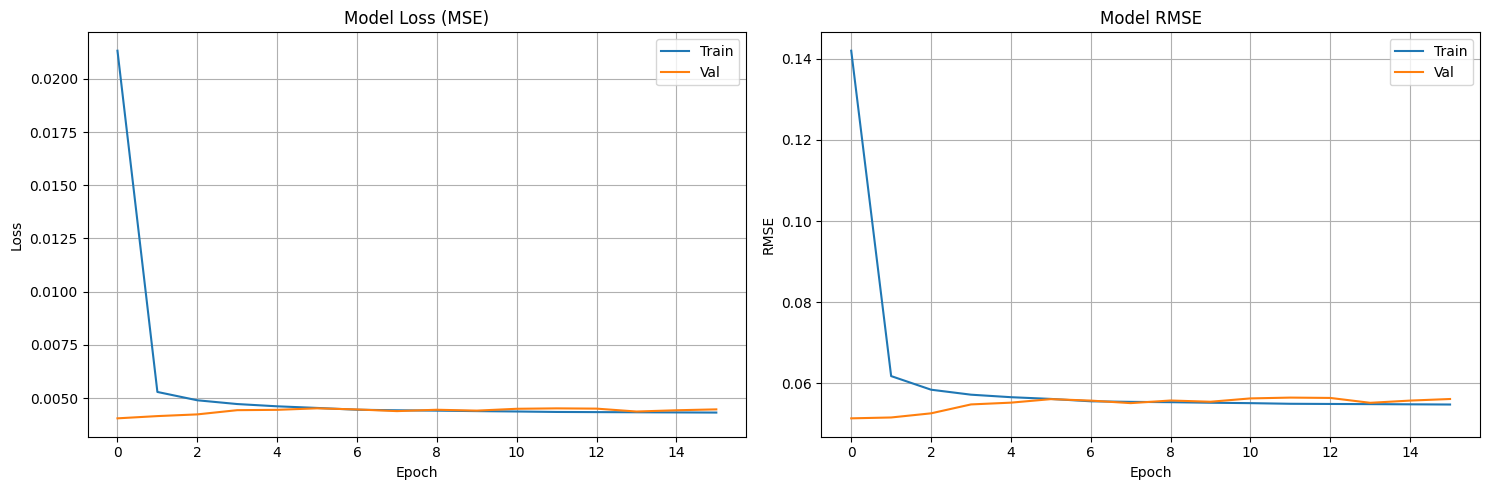

In [ ]:
"""Plots training and validation curves and saves them to the analytics directory."""

import matplotlib.pyplot as plt

ANALYTICS_DIR = "../analytics"
os.makedirs(ANALYTICS_DIR, exist_ok=True)


def plot_history(history):
    """Plots model loss and root mean squared error curves.

    Args:
        history: Keras History object.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Loss curve
    ax1.plot(history.history["loss"], label="Train")
    ax1.plot(history.history["val_loss"], label="Val")
    ax1.set_title("Model Loss (MSE)")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()
    ax1.grid(True)

    # RMSE curve
    ax2.plot(history.history["rmse"], label="Train")
    ax2.plot(history.history["val_rmse"], label="Val")
    ax2.set_title("Model RMSE")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("RMSE")
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.savefig(os.path.join(ANALYTICS_DIR, "dense_opt_training_history.png"))
    plt.show()


if "history" in locals():
    plot_history(history)

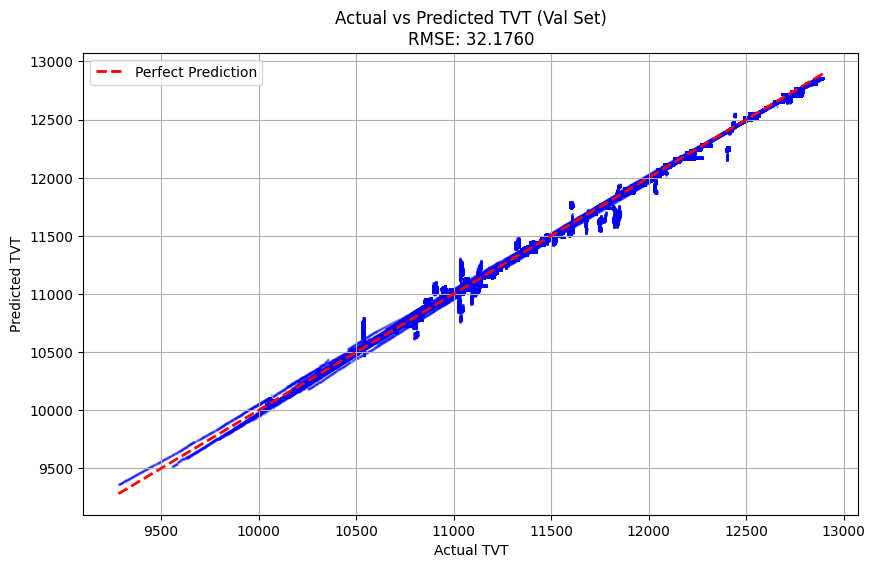

In [ ]:
def plot_pred_vs_actual(y_true, y_pred, val_rmse):
    """Plots predicted vs actual values on raw scale and saves it to analytics."""
    plt.figure(figsize=(10, 6))
    plt.scatter(np.array(y_true), np.array(y_pred), alpha=0.1, s=1, color="blue")

    # Draw perfect prediction line
    min_val = min(float(y_true.min()), float(y_pred.min()))
    max_val = max(float(y_true.max()), float(y_pred.max()))
    plt.plot(
        [min_val, max_val], [min_val, max_val], "r--", lw=2, label="Perfect Prediction"
    )

    plt.title(f"Actual vs Predicted TVT (Val Set)\nRMSE: {val_rmse:.4f}")
    plt.xlabel("Actual TVT")
    plt.ylabel("Predicted TVT")
    plt.legend()
    plt.grid(True)

    plt.savefig(os.path.join(ANALYTICS_DIR, "dense_opt_val_pred_vs_actual.png"))
    plt.show()


if "y_val_raw" in locals() and "yp_jnp" in locals():
    plot_pred_vs_actual(y_val_raw, yp_jnp, rmse)